## Subduction and Volcanism
Subduction is the geological process by which oceanic crust and lithosphere sink as coherent slabs into the mantle when two tectonic plates converge. This process provides a  fundamental driving force for plate tectonics and is responsible for many geological observations, including earthquakes, volcanic activity, and the formation of mountain ranges.

The frictional interface between the subducting slab and the overriding plate is capable of producing large-magnitude earthquakes, including megathrust events with moment magnitudes greater than 9.0. Moreover, the shear stress on the interface generated due to the relative motion of the downgoing plate relative to the overriding plate, produces heat that warms the surrounding mantle wedge. This can lead to accelerated dehydration reactions, releasing fluids lower its solidus, and generate arc volcanism.


<div>
<img src='./images/megathrust_eqs.png' width="500"/>
<figcaption align = "left"> Mw ≥ 5 earthquakes from 1900 to 2016 presumed to be on the subducting slab (green circles) and in the intraslab region (red circles). Image: Bilek and Lay (2018). </figcaption>
</div>

<div>
<img src='./images/volcanic_arcs.png' width="500"/>
<figcaption align = "left"> Global distribution of eruptions VEI ≥ 4 since 1750. Image: Palladino and Sottili (2012). </figcaption>
</div>

### Subduction plate interface zone

Scholz (1998) describes three possible stability regimes for
the typical subduction zone (see figure below):

- a stable zone aseismic creep relaxes all strains
- an unstable zone where episodic slip can occur, generating earthquakes
- a conditionally stable zone, where slip is generally stable but can be abrupt due to nearby ruptures

<div>
<img src='./images/subduction_interface_kinematics.png' width="600"/>
<figcaption align = "left"> Cartoon illustrating the frictional conditions at the subduction fault zone interface. Unstable contact areas (grey areas) provide nucleation sites for rupture Image: Bilek and Lay (2002). </figcaption>
</div>

## Frictional heating on the fault zone

Temperature increase on the slip zone can be computed using the half-space cooling model with uniform heat production (see section 4.27 in Turcotte and Schubert, 2002 for details) as:

\begin{equation*}
T_{sz} = T_0 + \frac{2\tau}{k}\left( \frac{u \kappa x}{\pi \cos \phi} \right)^{1/2} = T_0 + \frac{2\tau}{k}\left( \frac{u \kappa d_v}{\pi \cos \phi \sin \theta} \right)^{1/2}\tag 1
\end{equation*}

where $T_{sz}$ and $T_0$ is the temperature at the slip zone and at the surface, respectively, u is the speed at which the surface oceanic plate moves at an angle $\phi$ normal to the trench, $x$ is distance from the trench along the the subducting plate, $d_v$ is the depth from the surface, $\theta$ is the dip angle of the subduction, $k$ is the thermal conductivity, $\kappa$ is the thermal diffusivity of the plate, and $\tau$ is the mean stress on the fault.

For melting to occur, $T_{sz} = T_m$, i.e., melting temperature of the rock.

Using typical physical values for a subducting plate, we can compute the shear stress required to generate necessary melting at 125 km depth.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plate_speed = 0.1/(365*24*3600) # 10 cm/year
thermal_conductivity = 4 # W/m/K
thermal_diffusivity  = 1e-6 # m^2/s
dip_angle            = 45 # degrees

In [ ]:
def shear_stress_for_melting (shear_zone_temperature, depth):
    '''
    Inputs:
    ---------
    args  : meltingT in K, depth in m

    Output:
    ---------
    shear stress in Pa
    '''
    term_in_braces = thermal_diffusivity * depth * plate_speed / (np.pi * np.sin (np.radians (dip_angle)))
    return (shear_zone_temperature - 273.15) * thermal_conductivity / ( 2 * np.sqrt(term_in_braces) )

Let's assume melt temperature of 1473 K at 125 km depth to compute the interface stresses required for melt generation.

In [ ]:
melting_stresses = shear_stress_for_melting(1473, 125e3)
print (f'Shear stress required for melt generation: {melting_stresses/1e6:.2e} Pa')

Shear stress required for melt generation: 1.80e+02 Pa


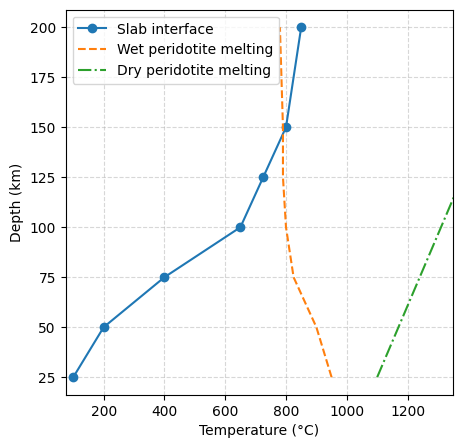

In [ ]:
# slab-surface temperatures discretized from Leenman 2020
interface_temperatures = np.array([100, 200, 400, 650, 725, 800, 850]) # in C
depths                 = np.array([25, 50, 75, 100, 125, 150, 200]) * 1e3 # in m
shear_stress           = np.ones_like(interface_temperatures)
wet_peridotite_melting_T = np.array([950, 900, 825, 800, 790, 790, 780]) # in C
dry_peridotite_melting_T = np.array([1100, 1170, 1240, 1310, 1380, 1450, 1580])

# plot interface temperatures and peridotite melting temperatures as a function of depth
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(interface_temperatures, depths/1e3, '-o', label='Slab interface')
ax.plot(wet_peridotite_melting_T, depths/1e3, '--', label='Wet peridotite melting')
ax.plot(dry_peridotite_melting_T, depths/1e3, '-.', label='Dry peridotite melting')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Depth (km)')
plt.grid(which='both', linestyle='--', alpha=0.5)

ax.set_xlim([75, 1350])
ax.legend(loc='upper left')

At about 150 km depth, melting can occur even without frictional heating, as the melting temperature reduces to about 1073 K due to the presence of fluids.

#### References
- Bilek, S. L., & Lay, T. (2002). Tsunami earthquakes possibly widespread manifestations of frictional conditional stability. Geophysical Research Letters, 29(14), 18-1.
- Bilek, S. L., & Lay, T. (2018). Subduction zone megathrust earthquakes. Geosphere, 14(4), 1468-1500.
- Leeman, W. P. (2020). Old/new subduction zone paradigms as seen from the Cascades. Frontiers in Earth Science, 8, 535879.
- Turcotte, D. L., & Schubert, G. (2002). Geodynamics. Cambridge University Press.

#### Further Reading
A comprehensive review of the thermal structure of subduction zone and their incorporation in numerical models can be found in the following papers:

- Van Keken, P. E., & Wilson, C. R. (2023). An introductory review of the thermal structure of subduction zones: I—motivation and selected examples. Progress in Earth and Planetary Science, 10(1), 42.
- Wilson, C. R., & Keken, P. E. V. (2023). An introductory review of the thermal structure of subduction zones: II. Numerical approach and validation.
- van Keken, P. E., & Wilson, C. R. (2023). An introductory review of the thermal structure of subduction zones: III—Comparison between models and observations. Progress in Earth and Planetary Science, 10(1), 57.

 &nbsp;<div style="text-align: right">  
    &rarr; <b>NEXT: [Forces on a slab](./2_forces_on_a_slab.ipynb) </b> <a href=""></a> &nbsp;&nbsp;
     <img src="../../../assets/education-gem-notebooks_icon.png" alt="icon"  style="width:4%">
  </div>